In [1]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys, os
# adding path to folder
sys.path.insert(0, '../tools/')

import matplotlib.pyplot as plt
plt.style.use('./cfg/my_custom_plot.mplstyle')

# use these lines on top of your matplotlib script
import matplotlib.ticker
class MyLocator(matplotlib.ticker.AutoMinorLocator):
    def __init__(self, n=4):
        super().__init__(n=n)
matplotlib.ticker.AutoMinorLocator = MyLocator        
 
# Now use matplotlib as usual.       
import matplotlib.pyplot as plt
plt.rcParams["xtick.minor.visible"] =  True
plt.rcParams["ytick.minor.visible"] =  True
import matplotlib.colors as mcolors  # Importing the correct module for colors
import plotly.graph_objects as go


from utils import load_dataset,load_keys, ParticleCode
# Load PDG Codes
pdg_tab = ParticleCode()

In [2]:
# Load PDG Codes
pdg_tab = ParticleCode()

plot_dir = './plots-gk/'
# Load datasets 
n_files = 998
location = "nersc"
df=load_dataset(n_files,'nersc')

Openning MiniRun 5 beta 2.a CAFs
Reading  998  files


877it [20:04,  1.37s/it]


In [11]:
#dimensions of the detector
anode_xs = np.array([-63.931, -3.069, 3.069, 63.931])
anode_ys = np.array([-19.8543, 103.8543]) - 42  # Subtract 42 from all y coordinates
anode_zs = np.array([-64.3163, -2.6837, 2.6837, 64.3163])
#Fiducial Volume
tpc_dist = 8.0
xbound = 63.931
ybound = 62.076
zbound = 64.3163


In [12]:
#find if an interaction is contained in FV
def isContainedFV(vx,vy,vz):
    tpc_dist = 10.0
    xbound = 63.931
    ybound = 62.076
    zbound = 64.3163

    if(
        abs(vx)<xbound-tpc_dist and
        abs(vx)>tpc_dist and
        abs(vy)<ybound-tpc_dist and
        abs(vz)>tpc_dist and
        abs(vz)<zbound-tpc_dist
    ): 
        return True
    else: return False

#finds distance of the track to vtx and length 
def calculate_track_properties(start_pos, end_pos, vtx_pos):
    track_length = np.linalg.norm(np.array(start_pos) - np.array(end_pos))
    vtx_distance = np.linalg.norm(np.array(start_pos) - np.array(vtx_pos))
    return track_length, vtx_distance

#TRUE: filter the true ccmunu fv signal to tracks that exit 2x2 downstream
def find_end_muon(ev_data, mask_signal):
    muon_out = np.zeros_like(mask_signal, dtype=bool)
    for vtx, value in enumerate(mask_signal):
        if value:
            n_tracks = ev_data['rec.mc.nu.prim..length'][vtx]
            n_pre = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx]) if vtx > 0 else 0
            
            # Scan over particles associated with this interaction
            for ip in range(n_pre, n_pre + n_tracks):
                if (ev_data['rec.mc.nu.prim.end_pos.z'][ip]>=zbound)&(mask_signal[vtx]==1):
                    muon_out[vtx] = True 
                    break  # No need to check further if a match is found
    return muon_out
   

In [13]:
#this gather TRUE INFO neutron induced proton info, neutrons percents in the signal, etc
num_neutrinos_total = 0
num_prim_neutrons_total =0 #num of primary neutrons in the simulation
num_neutrons_fv=0  #num of neutrons in the fiducial volume
num_neutrons_dv = 0 #num of neutrons in the detector
num_neutrons_signal =0 #num of neutrons on the signal: cc numu Ar fd
num_out_muon =0 

#store energies 
E_neutrino_all = []
E_neutrino_Ar = [] #store neutrino energy within FV with Ar
E_neutrino_dv_Ar = [] #store neutrino energy within detector with Ar
E_neutrino_fv_Ar = [] #store neutrino energy within FV with Ar
E_neutrino_signal = [] #store neutrino energy of signal ccnumu FV Ar
E_neutrino_w_prim_neutrons = [] #store neutrino energies of int that produced primary neutrons
E_prim_neutrons_signal = [] #store energies of the primary neutrons in the signal
E_neutron_parents = [] #store energy of the neutrons that are proton parents
E_neutrino_n_p = [] #store neutrino energy of the interactions that produced n->p
E_proton =[] #store energy of neutron induced protonse

#store proton tracks info
track_vtx_distances = [] #distance of the proton track to the vertex
track_lengths= [] #proton track lenght 
track_lengths2= []
track_vtx_distances2=[]
# Create lists to store the vertex positions of vtx that happen in FV
vertices_x = []
vertices_y = []
vertices_z = []

#store vertices of the signal that exit 2x2 downstream
vx_t=[]
vy_t=[]
vz_t=[]


for event in range(len(df)):

    ev_data= df.iloc[event]

    #Mask vertex on the detector volume
    mask_dv = (
                (ev_data['rec.mc.nu.vtx.x'] >= anode_xs[0]) & (ev_data['rec.mc.nu.vtx.x'] <= anode_xs[3]) &
                (ev_data['rec.mc.nu.vtx.y'] >= anode_ys[0]) & (ev_data['rec.mc.nu.vtx.y'] <= anode_ys[1]) &
                (ev_data['rec.mc.nu.vtx.z'] >= anode_zs[0]) & (ev_data['rec.mc.nu.vtx.z'] <= anode_zs[3]) 
                )
    
    #mask Ar in DV
    mask_dv_Ar = (
        mask_dv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)
    )

    #mask vertex on the fiducial volume
    mask_fv = (
        (abs(ev_data['rec.mc.nu.vtx.x'])<xbound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.x'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.y'])<ybound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])<zbound-tpc_dist)
    )
    #mask Ar in FV
    mask_fv_Ar = (
        mask_fv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)
    )
    #mask vertex on fv, Ar, CC numu
    mask_signal = (
        mask_fv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon) & 
        (ev_data['rec.mc.nu.iscc']==1) &
        (np.abs(ev_data['rec.mc.nu.pdg']) == pdg_tab.numu)
    )

    vertices_x.extend(ev_data['rec.mc.nu.vtx.x'][mask_signal])
    vertices_y.extend(ev_data['rec.mc.nu.vtx.y'][mask_signal])
    vertices_z.extend(ev_data['rec.mc.nu.vtx.z'][mask_signal])

    #some data we can gather directly:
    n_vtx = len(ev_data['rec.mc.nu.E']) 
    E_neutrino_all.extend(ev_data['rec.mc.nu.E'])
    num_neutrinos_total +=  ev_data['rec.mc.nu..length']
    E_neutrino_Ar.extend(ev_data['rec.mc.nu.E'][(ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)])
    E_neutrino_dv_Ar.extend(ev_data['rec.mc.nu.E'][mask_dv_Ar]) 
    E_neutrino_fv_Ar.extend(ev_data['rec.mc.nu.E'][mask_fv_Ar])  
    E_neutrino_signal.extend(ev_data['rec.mc.nu.E'][mask_signal]) #ccmunu df
    num_prim_neutrons_total += sum(ev_data['rec.mc.nu.nneutron']) #this is only primaries
    num_neutrons_dv += sum(ev_data['rec.mc.nu.nneutron'][mask_dv])
    num_neutrons_fv += sum(ev_data['rec.mc.nu.nneutron'][mask_fv])
    num_neutrons_signal += sum(ev_data['rec.mc.nu.nneutron'][mask_signal])

    signal_out_muon = find_end_muon(ev_data, mask_signal)
    num_out_muon += np.sum(signal_out_muon)

    vx_t.extend(ev_data['rec.mc.nu.vtx.x'][signal_out_muon])
    vy_t.extend(ev_data['rec.mc.nu.vtx.y'][signal_out_muon])
    vz_t.extend(ev_data['rec.mc.nu.vtx.z'][signal_out_muon])

    #now let's gather the data from neutrons that produced protons

    for vtx in range(n_vtx):  # Using num interactions directly as the range
    
        #if vtx it is not in the signal, skip vtx
        if (mask_signal[vtx]==False):
            continue
        else:
            #now check for neutrons with proton daughter 
            #a vtx can produce several neutrons, we need to ensure we include the vtx info only one time 
            #E.g. an vtx might have more than one neutron, but it's still same vtx.
            tracked_neutron_ids = set() #track the vtx that we already count
            n_prim = ev_data['rec.mc.nu.prim..length'][vtx] #num of total prim
            n_sec = ev_data['rec.mc.nu.sec..length'][vtx]   #num of total sec


            #Luis's trick to iterate between primaries/sec per vtx
            if vtx == 0:
                n_pred_prim = 0
                n_pred_sec = 0
            else:
                n_pred_prim = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx])
                n_pred_sec = np.sum(ev_data['rec.mc.nu.sec..length'][:vtx])

            #false if you haven't included that vtx, if a neutrons is found then True
            included_vertex=False  
            included_vertex_np = False  #to count neutrons that produced protons

            #iterates over all primaries of the interaction. 
            # This finds info from primary neutrons
            for ip in range(n_pred_prim, n_pred_prim + n_prim):
                if (ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron):
                    #Store energy of primary neutrons. Sanity-check: length must match num_prim_neutrons_signal
                    E_prim_neutrons_signal.append(ev_data['rec.mc.nu.prim.p.E'][ip])              
                    #save the neutrino energy of the vtx that produced at least one prim neutron
                    if included_vertex == False: 
                        E_neutrino_w_prim_neutrons.extend(ev_data['rec.mc.nu.E'][mask_signal])
                        included_vertex= True  #make true so we don't overcount the interactions/vertex
                    else: pass  #skip vtx if you already included it 

            # iterate over secondary particles to find neutron-induced protons
            for isec in range(n_pred_sec, n_pred_sec + n_sec):
                # check if any of the secondary particles are protons
                if ev_data['rec.mc.nu.sec.pdg'][isec] == pdg_tab.proton:
                    # if proton, save the G4 ID of the parent
                    proton_parent_id = ev_data['rec.mc.nu.sec.parent'][isec]
                    # iterate over primary particles to find parent 
                    for ip in range(n_pred_prim, n_pred_prim + n_prim):
                        if (
                            ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron and 
                            ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
                        ):
                            # This interaction has a proton produced by a neutron
                            if included_vertex_np == False:
                                E_neutrino_n_p.extend(ev_data['rec.mc.nu.E'][mask_signal]) #save energy of the interaction
                                included_vertex_np= True #make true so we don't overcount the interactions/vertex
                            else: pass #skip vtx if you already included it 

                            if proton_parent_id not in tracked_neutron_ids:
                                #vtx_n_p[vtx] = True
                                #get energies and calculate distance to vertex
                                E_neutron_parents.append(ev_data['rec.mc.nu.prim.p.E'][ip])
                                E_proton.append(ev_data['rec.mc.nu.sec.p.E'][isec])
                                tracked_neutron_ids.add(proton_parent_id)
                                #proton distance to vertex

                                track_length, vtx_distance = calculate_track_properties(
                                (ev_data['rec.mc.nu.sec.start_pos.x'][isec], ev_data['rec.mc.nu.sec.start_pos.y'][isec], ev_data['rec.mc.nu.sec.start_pos.z'][isec]),
                                (ev_data['rec.mc.nu.sec.end_pos.x'][isec], ev_data['rec.mc.nu.sec.end_pos.y'][isec], ev_data['rec.mc.nu.sec.end_pos.z'][isec]),
                                (ev_data['rec.mc.nu.vtx.x'][vtx], ev_data['rec.mc.nu.vtx.y'][vtx], ev_data['rec.mc.nu.vtx.z'][vtx])
                                )
                                track_lengths.append(track_length)
                                track_vtx_distances.append(vtx_distance)

In [ ]:

print(f'There are {num_prim_neutrons_total} primary neutrons in the simulation')
print(f'There are {num_neutrons_dv} prim neutrons in the DV, {num_neutrons_fv} in the FV, and  {num_neutrons_signal} in the signal')
print(f'There are {len(E_neutrino_w_prim_neutrons)} interactions in the signal that produced prim neutrons')
print(f'There are {len(E_proton)} neutron induced protons and {len(E_neutrino_n_p )} n->p interactions  ')
print(f'There are {len(vertices_x)} vertices in FV')

In [ ]:

plt.hist(E_neutrino_signal,bins=100,histtype='step',range=(0,20), color='pink', label=r'CC$\nu_\mu$')
plt.hist(E_neutrino_w_prim_neutrons,bins=100,histtype='step',range=(0,20), color='purple', label=r'CC$\nu_\mu$ $n$')
plt.hist(E_neutrino_n_p,bins=100,histtype='step',range=(0,20), color='cyan', label=r'CC$\nu_\mu$  $n\rightarrow p$')
plt.ylabel('Number of interactions')
plt.xlabel('Neutrino Energy [GeV]')
plt.title('DUNE 2x2 CAF - True Signal FV')
plt.legend()
#plt.yscale('log')
plt.show()

In [ ]:
plt.hist(track_vtx_distances,bins=90,histtype='step',range=[0,300], color='purple', density=True,label=r'p')
plt.title('DUNE 2x2 CAF - True Signal')
plt.xlabel(' Proton Vertex Distance (cm)')
plt.ylabel('Number of Protons')
#plt.yscale('log')
plt.show()

len(track_vtx_distances)

In [ ]:
plt.hist(track_lengths,bins=90,histtype='step',range=[0,15], color='purple', density=True,label=r'p')
plt.title('DUNE 2x2 CAF - True Signal')
plt.xlabel(' Proton Track Length (cm)')
plt.ylabel('Counts')
#plt.yscale('log')
plt.show()

In [ ]:
K_neutron_parents = [x - pdg_tab.neutron_mass/1000 for x in E_neutron_parents]
K_neutron_prim =[x - pdg_tab.neutron_mass/1000 for x in E_prim_neutrons_signal ]
plt.hist(K_neutron_prim,bins=70,histtype='step', color='purple', range= [0,12], label=r'CC$\nu_\mu$ $n$')
plt.hist(K_neutron_parents,bins=70,histtype='step', color='cyan',  range= [0,12],  label=r'CC$\nu_\mu$  $n\rightarrow p$')
plt.ylabel('Number of neutrons')
plt.title('DUNE 2x2 CAF - True Signal')
plt.xlabel(' Neutron Kinetic Energy [GeV]')
plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
K_neutron= [x - pdg_tab.neutron_mass/1000 for x in E_neutron_parents]
K_proton =[x - pdg_tab.proton_mass/1000 for x in E_proton ]


plt.hist2d(K_neutron, K_proton, bins=90, norm=mcolors.LogNorm(), cmap='viridis')
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.colorbar(label='Counts')
plt.xlabel('Neutron Kinetic Energy (GeV)')
plt.ylabel('Proton Kinetic Energy (GeV)')
plt.title('DUNE 2X2 CAF - True Signal')
plt.show()

In [ ]:
# Data and positions
portions = [(num_neutrinos_total), len(E_neutrino_Ar), len(E_neutrino_dv_Ar), len(E_neutrino_fv_Ar), len(E_neutrino_signal), len(E_neutrino_w_prim_neutrons), len(E_neutron_parents ) ]/(0.01*num_neutrinos_total)
positions = [0,1,2,3,4,5,6]
# Plot
plt.step(positions, portions, where='mid', color='purple', label='Data Line')
plt.yscale('log')
plt.xticks(positions,[r'All',r'Ar', r'DV', r'FV', r'CC $\nu_{\mu}$', r'$n_{\text{prim}}$', r'$n_{\text{prim}} \rightarrow p$'],rotation=30)
for i, value in enumerate(portions):
    if i == 0:continue
    plt.text(positions[i], value, f'{value:.2f}%', ha='center', va='bottom', fontsize=8)
plt.yscale('log')
plt.title('DUNE 2X2 CAF - True Signal Cuts')
plt.ylabel('Percent of Interactions (%)')
#plt.legend()
plt.show()

data = {
    'Cut': ['Total Simulation', 'neutrino-Argon', 'Detector Volume',
            'Fiducial Volume (FV)', 'CC muon neutrino', 'Primary Neutrons', 'Neutron Induced Proton'],
    'Interactions': [num_neutrinos_total, len(E_neutrino_Ar), len(E_neutrino_dv_Ar), len(E_neutrino_fv_Ar), len(E_neutrino_signal), len(E_neutrino_w_prim_neutrons), len(E_neutron_parents)],
    'Percent (%)': np.round(np.array([num_neutrinos_total, len(E_neutrino_Ar), len(E_neutrino_dv_Ar), len(E_neutrino_fv_Ar), len(E_neutrino_signal), len(E_neutrino_w_prim_neutrons), len(E_neutron_parents)]) / num_neutrinos_total * 100, 4)
}

df_table_with_names = pd.DataFrame(data)

# Display the DataFrame with formatting, reset index to remove the default index column
df_table_with_names.reset_index(drop=True).style.format({"Percent (%)": "{:.2f}"})


In [61]:
x_boundaries = np.array([-63.931, -3.069, 3.069, 63.931])
y_boundaries = np.array([-61.8543, 61.8543])
z_boundaries = np.array([-64.3163,  -2.6837, 2.6837, 64.3163])

def draw_cathode_planes(x_boundaries, y_boundaries, z_boundaries, **kwargs):
    
    traces = []
    for i_z in range(int(len(z_boundaries)/2)):
        for i_x in range(int(len(x_boundaries)/2)):
            z, y = np.meshgrid(np.linspace(z_boundaries[i_z * 2], z_boundaries[i_z * 2 + 1], 2), np.linspace(y_boundaries.min(), y_boundaries.max(),2))
            x = (x_boundaries[i_x * 2] + x_boundaries[i_x * 2 + 1]) * 0.5 * np.ones(z.shape)

            traces.append(go.Surface(x=x, y=y, z=z, **kwargs))

    return traces

def draw_anode_planes(x_boundaries, y_boundaries, z_boundaries, **kwargs):
    
    traces = []
    for i_z in range(int(len(z_boundaries)/2)):
        for i_x in range(int(len(x_boundaries))):           
            z, y = np.meshgrid(np.linspace(z_boundaries[i_z * 2], z_boundaries[i_z * 2 + 1], 2), np.linspace(y_boundaries.min(), y_boundaries.max(),2))
            x = x_boundaries[i_x] * np.ones(z.shape)

            traces.append(go.Surface(x=x, y=y, z=z, **kwargs))
    
    return traces


traces_anode = draw_anode_planes(x_boundaries, y_boundaries, z_boundaries)
traces_cathode = draw_cathode_planes(x_boundaries, y_boundaries, z_boundaries)

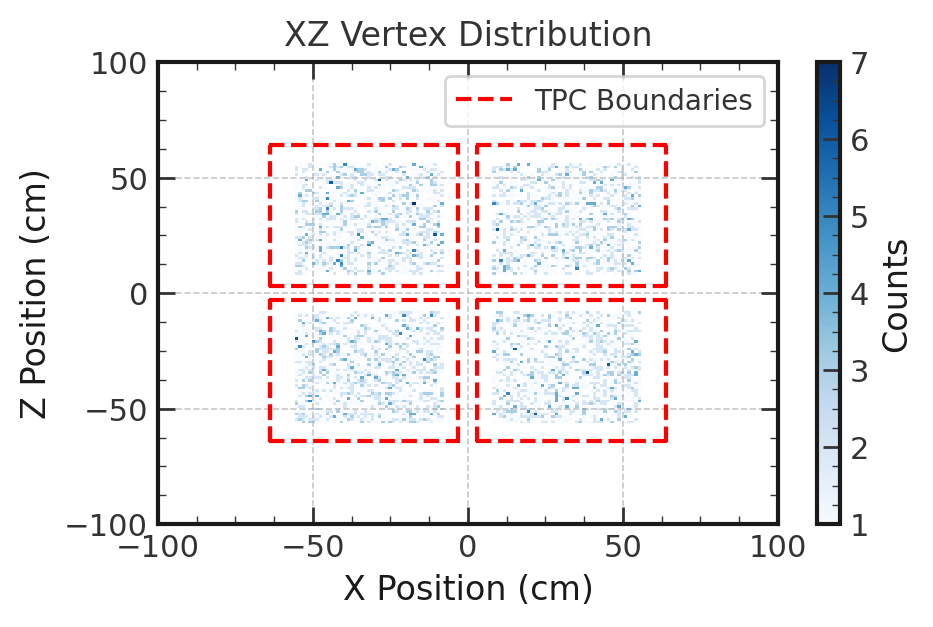

In [62]:
plt.hist2d(vertices_x, vertices_z, bins=100, cmap='Blues', cmin=0.01)
for i in range(0,8):
    plt.plot(traces_anode[i]['z'][1], traces_anode[i]['x'][1], 'r--')
    plt.plot(traces_anode[i]['x'][1], traces_anode[i]['z'][1], 'r--')
plt.plot(traces_anode[0]['x'][1], traces_anode[0]['z'][1],'r--',label='TPC Boundaries')
plt.title('XZ Vertex Distribution')
plt.xlabel('X Position (cm)')
plt.ylabel('Z Position (cm)')
plt.colorbar(label='Counts')
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.legend()

In [ ]:
plt.hist2d(vertices_z, vertices_y, bins=100, cmap='Blues', cmin=0.01)
for i in range(0,8):
    plt.plot(traces_anode[i]['z'][1], traces_anode[i]['y'][1], 'r--')
#     plt.plot(traces_anode[i]['y'][1], traces_anode[i]['z'][1], 'r--')
plt.plot([-traces_anode[0]['y'][1][1], traces_anode[0]['y'][1][1]],'r--',label='TPC Boundaries')
plt.plot([-64.3163,-64.3163 ],[-61.8543,61.8543], 'r--')
plt.plot([64.3163,64.3163 ],[-61.8543,61.8543], 'r--')
plt.plot([-2.6837,-2.6837 ],[-61.8543,61.8543], 'r--')
plt.plot([-61.8543,-2.6837], [-64.3163,-64.3163 ],'r--')
plt.plot([61.8543,2.6837], [-64.3163,-64.3163 ],'r--')
plt.title('YZ Vertex Distribution')
plt.xlabel('Z Position (cm)')
plt.ylabel('Y Position (cm)')
plt.colorbar(label='Counts')
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.legend()

# Reconstructed Signal


In [6]:
#cut: signal requiring a vtx that produced a reco sec/prim muon 
def signal_definition(ev_data, pdg, mask):
    signal = mask.copy()  # Create a copy of the mask to avoid modifying the original
    # Iterate over the interactions in fv
    for vtx, bool_value in enumerate(mask):
        n_particles = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        muon_found = False
        
        # If the mask is False for this vertex, skip it
        if not bool_value:
            continue
        else:
            # Check if there's any primary muon in the current interaction
            muon_found = np.any(
                (ev_data['rec.common.ixn.dlp.part.dlp.pdg'][n_pre:n_pre + n_particles] == pdg)
            )
        # Update the signal mask based on whether a muon was found
        signal[vtx] = muon_found
          
    return signal

#cut: signal requiring vtx that produced reco prim muon
def signal_definition_prim(ev_data, pdg, mask):
    signal = mask.copy()  # Create a copy of the mask to avoid modifying the original
    # Iterate over the interactions in fv
    for vtx, bool_value in enumerate(mask):
        n_particles = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        muon_found = False
        
        # If the mask is False for this vertex, skip it
        if not bool_value:
            continue
        else:
            # Check if there's any primary muon in the current interaction
            muon_found = np.any(
                (ev_data['rec.common.ixn.dlp.part.dlp.primary'][n_pre:n_pre + n_particles] == 1) &
                (ev_data['rec.common.ixn.dlp.part.dlp.pdg'][n_pre:n_pre + n_particles] == pdg)
            )
        # Update the signal mask based on whether a muon was found
        signal[vtx] = muon_found
          
    return signal

#cut: require a reco vtx to produce a reco track 
#cut: require reco vtx to produce track that exit 2x2 downstream
def track_selection_signal(ev_data):
    # Sample data (assuming these are numpy arrays or lists of coordinates)
    x_start_track  = ev_data['rec.nd.lar.dlp.tracks.start.x']
    y_start_track = ev_data['rec.nd.lar.dlp.tracks.start.y']
    z_start_track = ev_data['rec.nd.lar.dlp.tracks.start.z']

    z_end_track = ev_data['rec.nd.lar.dlp.tracks.end.z']

    x_coords_vtx = ev_data['rec.common.ixn.dlp.vtx.x']
    y_coords_vtx = ev_data['rec.common.ixn.dlp.vtx.y']
    z_coords_vtx = ev_data['rec.common.ixn.dlp.vtx.z']


    # Stack the coordinates into a single 2D array
    position_vtx = np.vstack((x_coords_vtx, y_coords_vtx, z_coords_vtx)).T
    start_track = np.vstack((x_start_track, y_start_track, z_start_track)).T

    track_on_vtx = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)
    track_out = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

    for vtx in range(len(ev_data['rec.common.ixn.dlp.vtx.x'])):
        n_reco_tracks = ev_data['rec.nd.lar.dlp.tracks..length'][vtx]
        n_pre = np.sum(ev_data['rec.nd.lar.dlp.tracks..length'][:vtx]) if vtx > 0 else 0
        
        vertex_position = position_vtx[vtx]
        # Scan over particles associated with this interaction
        found_match = False
        for ip in range(n_pre, n_pre + n_reco_tracks):
            if np.array_equal(vertex_position, start_track[ip]):
                found_match = True
                #if the track is found, then check if the track also goes out the boundary
                if (z_end_track[ip] >= zbound):
                    track_out[vtx] = True 
                break  # No need to check further if a match is found

        track_on_vtx[vtx] = found_match
    return track_on_vtx,  track_out


In [9]:
#check if a true proton was neutron-induced 
def was_neutron_induced(ev_data, vtx_t, proton_parent_id):
    #iterates over primaries to find parent
    neutron_induced = False
    n_prim =ev_data['rec.mc.nu.prim..length'][vtx_t]
    n_pred_prim = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx_t]) if vtx_t >0 else 0
    for ip in range(n_pred_prim, n_pred_prim + n_prim):
        if (
            ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron and 
            ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
        ):
            neutron_induced=True
    return neutron_induced 


#find the best match of a reco particle [ip]
def find_best_match(ev_data, ip):   
    #given the index of a reco particle, finds its best match
    truth_length = ev_data['rec.common.ixn.dlp.part.dlp.truth..length'][ip]
    truth_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp.truth..length'][:ip])
    max_overlap = 0
    best_match_idx = 0
    best_match_type = 0
    best_match_pdg=None

    for tp in range(truth_pre, truth_pre + truth_length):
        temp_overlap = ev_data['rec.common.ixn.dlp.part.dlp.truthOverlap'][tp]
        temp_tp_match = ev_data['rec.common.ixn.dlp.part.dlp.truth.part'][tp]
        temp_tp_type = ev_data['rec.common.ixn.dlp.part.dlp.truth.type'][tp]  # 1 prim and 3 second
        if temp_overlap > max_overlap:
            max_overlap = temp_overlap
            best_match_idx = temp_tp_match
            best_match_type = temp_tp_type

    if(best_match_type==3):
        best_match_pdg = ev_data['rec.mc.nu.sec.pdg'][best_match_idx]
    elif(best_match_type==1):
        best_match_pdg = ev_data['rec.mc.nu.prim.pdg'][best_match_idx]

    # Find the vertex where the best match index belongs in truth
    vtx_t = None
    for i in range(len(ev_data['rec.mc.nu.sec..length'])):
        p_in_vtx = np.sum(ev_data['rec.mc.nu.sec..length'][:i+1])  # Include the current vertex
        if best_match_idx <= p_in_vtx:
            vtx_t = i
            break
    return best_match_idx, best_match_type, best_match_pdg, vtx_t


#Gather the true info of the best match particles  
def get_match_truth_data(ev_data, vtx_t, best_match_idx):
    #store truth data
    match_truth_data = {
        'track_length_truth': None,
        'vtx_distance_truth': None,
        'E_neutrino': None,
        'is_in_FV': None
    }

    # Calculate track properties
    track_length_truth, vtx_distance_truth = calculate_track_properties(
        (ev_data['rec.mc.nu.sec.start_pos.x'][best_match_idx], 
         ev_data['rec.mc.nu.sec.start_pos.y'][best_match_idx],
         ev_data['rec.mc.nu.sec.start_pos.z'][best_match_idx]
        ),
        (ev_data['rec.mc.nu.sec.end_pos.x'][best_match_idx], 
         ev_data['rec.mc.nu.sec.end_pos.y'][best_match_idx],
         ev_data['rec.mc.nu.sec.end_pos.z'][best_match_idx]
        ),
        (ev_data['rec.mc.nu.vtx.x'][vtx_t],
         ev_data['rec.mc.nu.vtx.y'][vtx_t],
         ev_data['rec.mc.nu.vtx.z'][vtx_t]
        )
    )
    #Update the dictionary with calculated values, vertex index, E int
    match_truth_data['E_neutrino'] = ev_data['rec.mc.nu.E'][vtx_t]
    match_truth_data['is_in_FV'] = isContainedFV(ev_data['rec.mc.nu.vtx.x'][vtx_t], ev_data['rec.mc.nu.vtx.y'][vtx_t], ev_data['rec.mc.nu.vtx.z'][vtx_t])
    match_truth_data['track_length_truth'] = track_length_truth
    match_truth_data['vtx_distance_truth'] = vtx_distance_truth

    return match_truth_data


#Gather reco info of the candidates that passed all filters/cuts
def get_match_reco_data(ev_data, vtx_r, ip):
    #store data dict
    match_reco_data = {
        'track_length_reco': None,
        'vtx_distance_reco': None,
        'E_neutrino': None,
        'E_proton': None
    }
    #calculate track info
    track_length_reco, vtx_distance_reco = calculate_track_properties(
        (ev_data['rec.common.ixn.dlp.part.dlp.start.x'][ip],
         ev_data['rec.common.ixn.dlp.part.dlp.start.y'][ip],
         ev_data['rec.common.ixn.dlp.part.dlp.start.z'][ip]
        ),
        (ev_data['rec.common.ixn.dlp.part.dlp.end.x'][ip],
         ev_data['rec.common.ixn.dlp.part.dlp.end.y'][ip],
         ev_data['rec.common.ixn.dlp.part.dlp.end.z'][ip]
        ),
        (ev_data['rec.common.ixn.dlp.vtx.x'][vtx_r],
         ev_data['rec.common.ixn.dlp.vtx.y'][vtx_r],
         ev_data['rec.common.ixn.dlp.vtx.z'][vtx_r]
        )
    )
    #Update the dictionary with calculated values, vertex index, reco E
    match_reco_data['E_proton'] = ev_data['rec.common.ixn.dlp.part.dlp.E'][ip]
    match_reco_data['E_proton'] = ev_data['rec.common.ixn.dlp.part.dlp.E'][ip]
    match_reco_data['track_length_reco'] = track_length_reco
    match_reco_data['vtx_distance_reco'] = vtx_distance_reco
    
    return match_reco_data

In [55]:
#store num reco vtx for the cuts
num_neutrinos_dv_r=0 # in dv
num_neutrinos_fv_r=0 # in fv
num_neutrinos_muons = 0 #produced reco muon
num_neutrinos_muon_fv = 0 #produced reco muon in fv
num_neutrinos_prim_mu_fv=0 #produced prim muon in fv
#for tracks
num_track_fv = 0 # produced a track in fv
num_track_vtx_fv =0 #produced track that stat on vtx
num_track_vtx_out_fv=0 #produced track start on vtx and exit 2x2 downstream
    
#store track length and distance to vtx 
track_lenghts_match_truth = [] #true particles best match 
vtx_distances_match_truth =[]  
track_lenghts_reco = []  #reco particles candidates
vtx_distances_reco =[]

#positions of the vtx that passed the reco signal cuts
vtx_x_signal=[]
vtx_y_signal=[]
vtx_z_signal=[]
#positions of the vtx the reco candidates
vtx_x_candidates=[]
vtx_y_candidates=[]
vtx_z_candidates=[]

for ev in range(len(df)):

    ev_data = df.iloc[ev]
     
    #------------------------ true masks -----------
    mask_dv = (
                (ev_data['rec.mc.nu.vtx.x'] >= anode_xs[0]) & (ev_data['rec.mc.nu.vtx.x'] <= anode_xs[3]) &
                (ev_data['rec.mc.nu.vtx.y'] >= anode_ys[0]) & (ev_data['rec.mc.nu.vtx.y'] <= anode_ys[1]) &
                (ev_data['rec.mc.nu.vtx.z'] >= anode_zs[0]) & (ev_data['rec.mc.nu.vtx.z'] <= anode_zs[3]) 
                )
    
    #mask Ar in DV
    mask_dv_Ar = (
        mask_dv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)
    )

    #mask vertex on the fiducial volume
    mask_fv = (
        (abs(ev_data['rec.mc.nu.vtx.x'])<xbound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.x'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.y'])<ybound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])<zbound-tpc_dist)
    )
    #mask Ar in FV
    mask_fv_Ar = (
        mask_fv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)
    )
    #mask vertex on fv, Ar, CC numu
    mask_signal = (
        mask_fv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon) & 
        (ev_data['rec.mc.nu.iscc']==1) &
        (np.abs(ev_data['rec.mc.nu.pdg']) == pdg_tab.numu)
    )



   #---------Reco masks---------------

    mask_dv_r = (
        (ev_data['rec.common.ixn.dlp.vtx.x'] >= anode_xs[0]) & (ev_data['rec.common.ixn.dlp.vtx.x'] <= anode_xs[3]) &
        (ev_data['rec.common.ixn.dlp.vtx.y'] >= anode_ys[0]) & (ev_data['rec.common.ixn.dlp.vtx.y'] <= anode_ys[1]) &
        (ev_data['rec.common.ixn.dlp.vtx.z'] >= anode_zs[0]) & (ev_data['rec.common.ixn.dlp.vtx.z'] <= anode_zs[3]) 
    )
    
    #mask vertex on the fiducial volume
    mask_fv_r = (
        (abs(ev_data['rec.common.ixn.dlp.vtx.x'])<xbound-tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.x'])>tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.y'])<ybound-tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z'])>tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z'])<zbound-tpc_dist)
    )
    
    num_neutrinos_dv_r += np.sum(mask_dv_r)
    num_neutrinos_fv_r += np.sum(mask_fv_r)
    #signals muons + fv
    signal_fv_muons = signal_definition(ev_data,  pdg_tab.muon, mask_fv_r)  
    num_neutrinos_muon_fv += np.sum(signal_fv_muons) 
    #signal prim muon in fv 
    signal_prim_muon_fv = signal_definition_prim(ev_data,  pdg_tab.muon, mask_fv_r)
    num_neutrinos_prim_mu_fv += np.sum(signal_prim_muon_fv) 
    #signal tracks in fv
    signal_tracks_fv= (ev_data['rec.nd.lar.dlp.tracks..length'] != 0) & (mask_fv_r)
    num_track_fv += np.sum(signal_tracks_fv)
    #get the tracks on vertex
    tracks_vtx, track_vtx_out = track_selection_signal(ev_data)
    tracks_vtx_fv = (tracks_vtx) & (mask_fv_r) #get them now in fv
    tracks_vtx_out_fv = (track_vtx_out) & (mask_fv_r)
    num_track_vtx_fv += np.sum(tracks_vtx_fv)
    num_track_vtx_out_fv += np.sum(tracks_vtx_out_fv)



    for vtx_r, value in enumerate(tracks_vtx_out_fv):
        if value == True:
            n_reco_particles = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx_r]
            n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx_r]) if vtx_r>0 else 0
            
            #store info of the vertices that passsed the cuts
            vtx_x_signal.append(ev_data['rec.common.ixn.dlp.vtx.x'][vtx_r])
            vtx_y_signal.append(ev_data['rec.common.ixn.dlp.vtx.y'][vtx_r])
            vtx_z_signal.append(ev_data['rec.common.ixn.dlp.vtx.z'][vtx_r])
            
            # Scan over particles associated with this ixn 
            for ip in range(n_pre, n_pre + n_reco_particles):
                if (
                    ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip] == 0 and
                    ev_data['rec.common.ixn.dlp.part.dlp.pdg'][ip] == pdg_tab.proton 
                ):  
                    #if the particle was reco sec proton, find best match
                    best_match_idx, best_match_type, best_match_pdg, vtx_t = find_best_match(ev_data,ip)
                    if (best_match_pdg == pdg_tab.proton and best_match_type == 3):
                        #if best match is also sec proton, check if parent is neutron
                        proton_parent_id = ev_data['rec.mc.nu.sec.parent'][best_match_idx]
                        neutron_induced=was_neutron_induced(ev_data,vtx_t, proton_parent_id)

                        if neutron_induced == True: 
                            #truth tracks
                          
                            #if ev_data['rec.mc.nu.E'][vtx_t] in ev_data['rec.mc.nu.E'][mask_signal]:
                            match_truth_data = get_match_truth_data(ev_data, vtx_t, best_match_idx)
                            track_lenghts_match_truth.append(match_truth_data['track_length_truth'])
                            vtx_distances_match_truth.append(match_truth_data['vtx_distance_truth'])
                            #reco tracks
                            match_reco_data = get_match_reco_data(ev_data, vtx_r,ip)
                            track_lenghts_reco.append(match_reco_data['track_length_reco'])
                            vtx_distances_reco.append(match_reco_data['vtx_distance_reco'])
                            #store position of the vertices of the candidaes
                            vtx_x_candidates.append(ev_data['rec.common.ixn.dlp.vtx.x'][vtx_r])
                            vtx_y_candidates.append(ev_data['rec.common.ixn.dlp.vtx.y'][vtx_r])
                            vtx_z_candidates.append(ev_data['rec.common.ixn.dlp.vtx.z'][vtx_r])
print(len(track_lenghts_reco), len(track_lenghts_match_truth))


152 152


In [49]:
len(vtx_x_candidates)

152

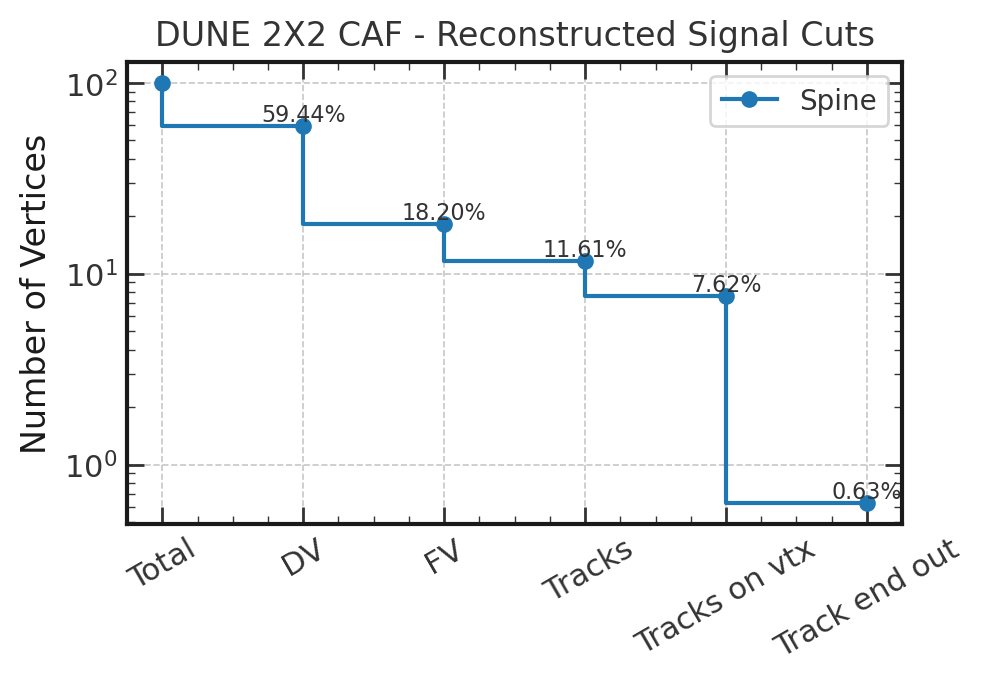

,Cut,Eventss,Percent (%)
0,Total Simulation,260322,100.000000
1,Detector Volume (DV),154740,59.441768
2,Fiducial Volume (FV),47377,18.199384
3,Fiducial Volume track,30230,11.612541
4,Track on vtx,19847,7.624019
5,Track out,1642,0.630757


In [39]:
n_vtx_total=np.sum(df['rec.common.ixn.dlp..length'])
portions=[n_vtx_total,  num_neutrinos_dv_r ,num_neutrinos_fv_r ,  num_track_fv, num_track_vtx_fv, num_track_vtx_out_fv]/((0.01*n_vtx_total))
positions = [0,1,2,3,4,5]
plt.step(positions,portions,marker='o',label='Spine')

plt.xticks(positions,[r'Total', r'DV', r'FV', r' Tracks', r'Tracks on vtx', r'Track end out' ],rotation=30)
for i, value in enumerate(portions):
    if i == 0:continue
    plt.text(positions[i], value, f'{value:.2f}%', ha='center', va='bottom', fontsize=8)
plt.yscale('log')
plt.title('DUNE 2X2 CAF - Reconstructed Signal Cuts')
plt.ylabel('Number of Vertices')
plt.legend()
plt.show()

data = {
    'Cut': ['Total Simulation', 'Detector Volume (DV)', 
               'Fiducial Volume (FV)', 
               'Fiducial Volume track', 'Track on vtx', 'Track out'],
    'Eventss': [n_vtx_total,  num_neutrinos_dv_r ,num_neutrinos_fv_r ,  num_track_fv, num_track_vtx_fv, num_track_vtx_out_fv],
    'Percent (%)': portions
}

# Creating the DataFrame with the metric names as rows
df_table_with_names = pd.DataFrame(data)
df_table_with_names

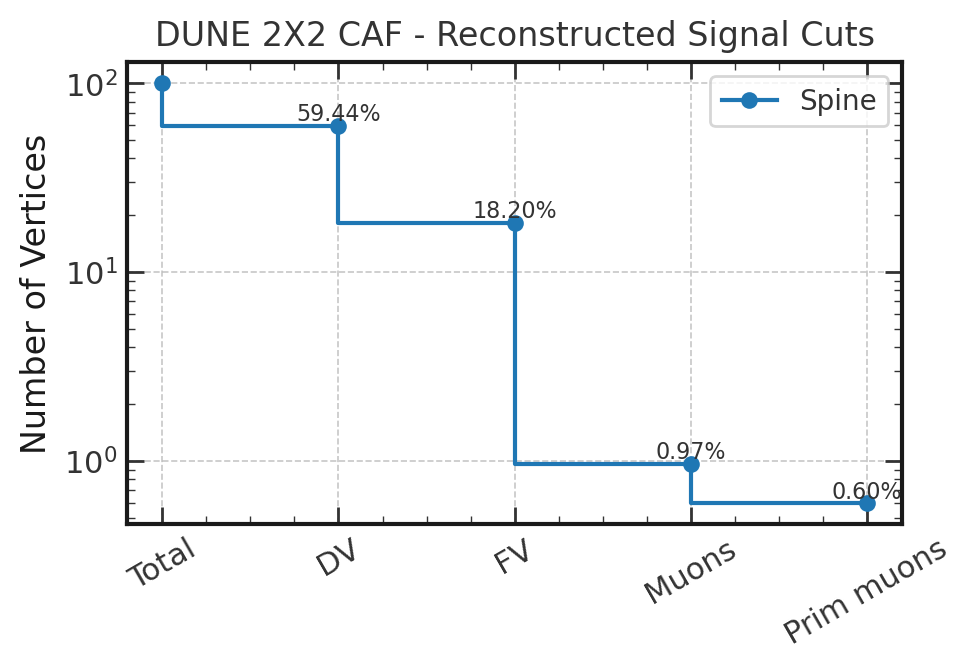

,Cut,Eventss,Percent (%)
0,Total Simulation,260322,100.000000
1,Detector Volume (DV),154740,59.441768
2,Fiducial Volume (FV),47377,18.199384
3,FV Muon,2525,0.969953
4,FV Prim Muon,1556,0.597721


In [40]:
count=np.sum(df['rec.common.ixn.dlp..length'])
portions=[count/(0.01*count),  num_neutrinos_dv_r/(0.01*count),  num_neutrinos_fv_r/(0.01*count),  num_neutrinos_muon_fv/(0.01*count), num_neutrinos_prim_mu_fv/(0.01*count)]
positions = [0,1,2,3,4]
plt.step(positions,portions,marker='o',label='Spine')

plt.xticks(positions,[r'Total', r'DV', r'FV', r'Muons' , r'Prim muons' ],rotation=30)
for i, value in enumerate(portions):
    if i == 0:continue
    plt.text(positions[i], value, f'{value:.2f}%', ha='center', va='bottom', fontsize=8)
plt.yscale('log')
plt.title('DUNE 2X2 CAF - Reconstructed Signal Cuts')
plt.ylabel('Number of Vertices')
plt.legend()
plt.show()

data = {
    'Cut': ['Total Simulation', 'Detector Volume (DV)', 
               'Fiducial Volume (FV)', 
               'FV Muon',
               'FV Prim Muon'],
    'Eventss': [count,  num_neutrinos_dv_r,  num_neutrinos_fv_r,  num_neutrinos_muon_fv, num_neutrinos_prim_mu_fv],
    'Percent (%)': portions
}

# Creating the DataFrame with the metric names as rows
df_table_with_names = pd.DataFrame(data)
df_table_with_names

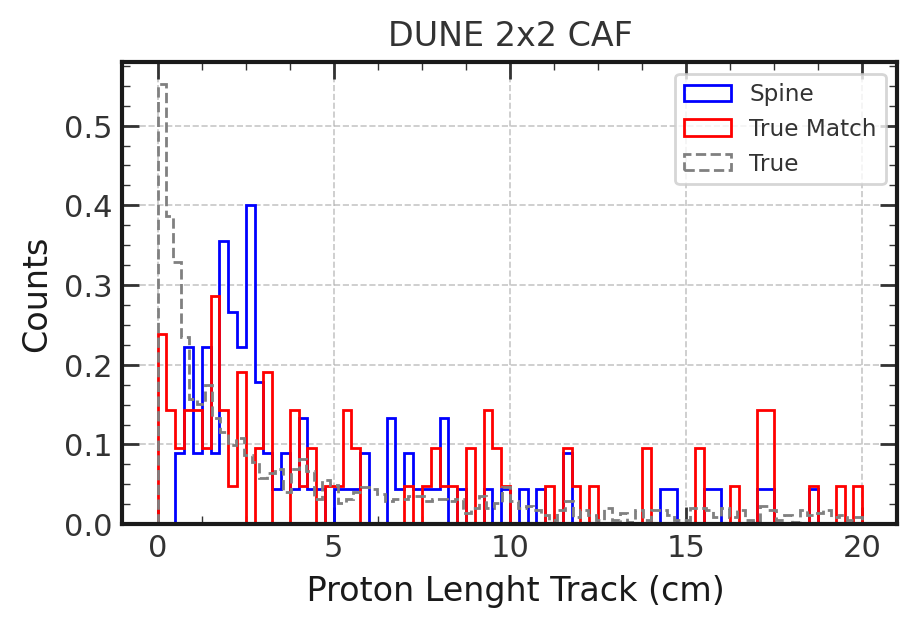

In [28]:
plt.hist(track_lenghts_reco,bins=80,histtype='step', range=[0,20], color='blue', density=True,label=r'Spine')
plt.hist(track_lenghts_match_truth,bins=80,histtype='step',range=[0,20], color='red',  density=True,label=r'True Match')
plt.hist(track_lengths,bins=90,histtype='step',range=[0,20], color='gray', linestyle='--', density=True,label=r'True')
plt.title('DUNE 2x2 CAF')
plt.xlabel(' Proton Lenght Track (cm)')
plt.ylabel('Counts')
plt.legend()
#plt.yscale('log')
plt.legend(loc='upper right', fontsize='small') 
plt.show()

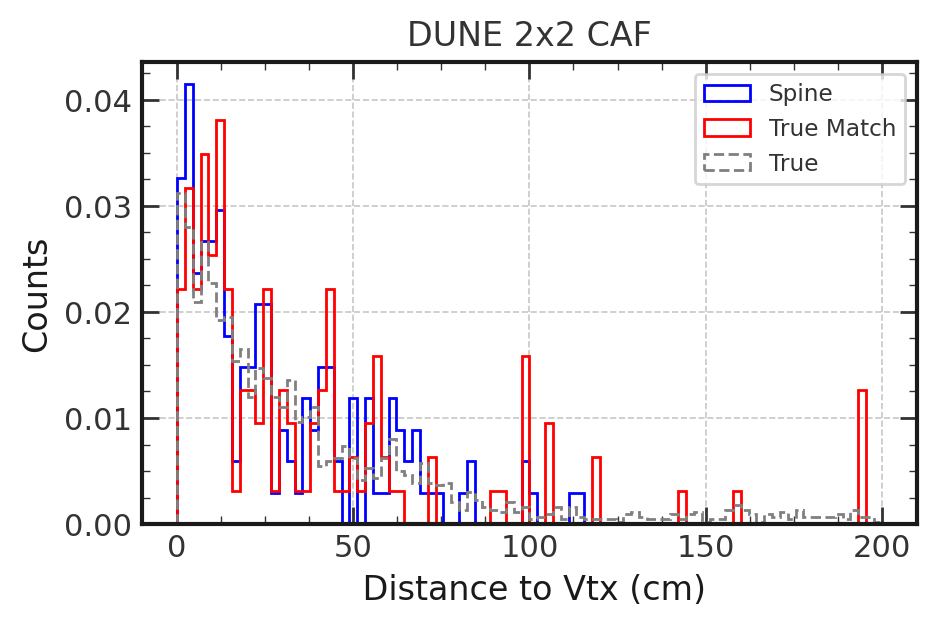

In [41]:
plt.hist(vtx_distances_reco,bins=90,histtype='step', range=[0,200], color='blue', density=True,label=r'Spine')
plt.hist(vtx_distances_match_truth,bins=90,histtype='step',range=[0,200], color='red',  density=True,label=r'True Match')
plt.hist(track_vtx_distances,bins=90,histtype='step',range=[0,200], color='gray', linestyle='--', density=True,label=r'True')
plt.title('DUNE 2x2 CAF')
plt.xlabel(' Distance to Vtx (cm)')
plt.ylabel('Counts')
plt.legend()
#plt.yscale('log')
plt.legend(loc='upper right', fontsize='small') 
plt.show()

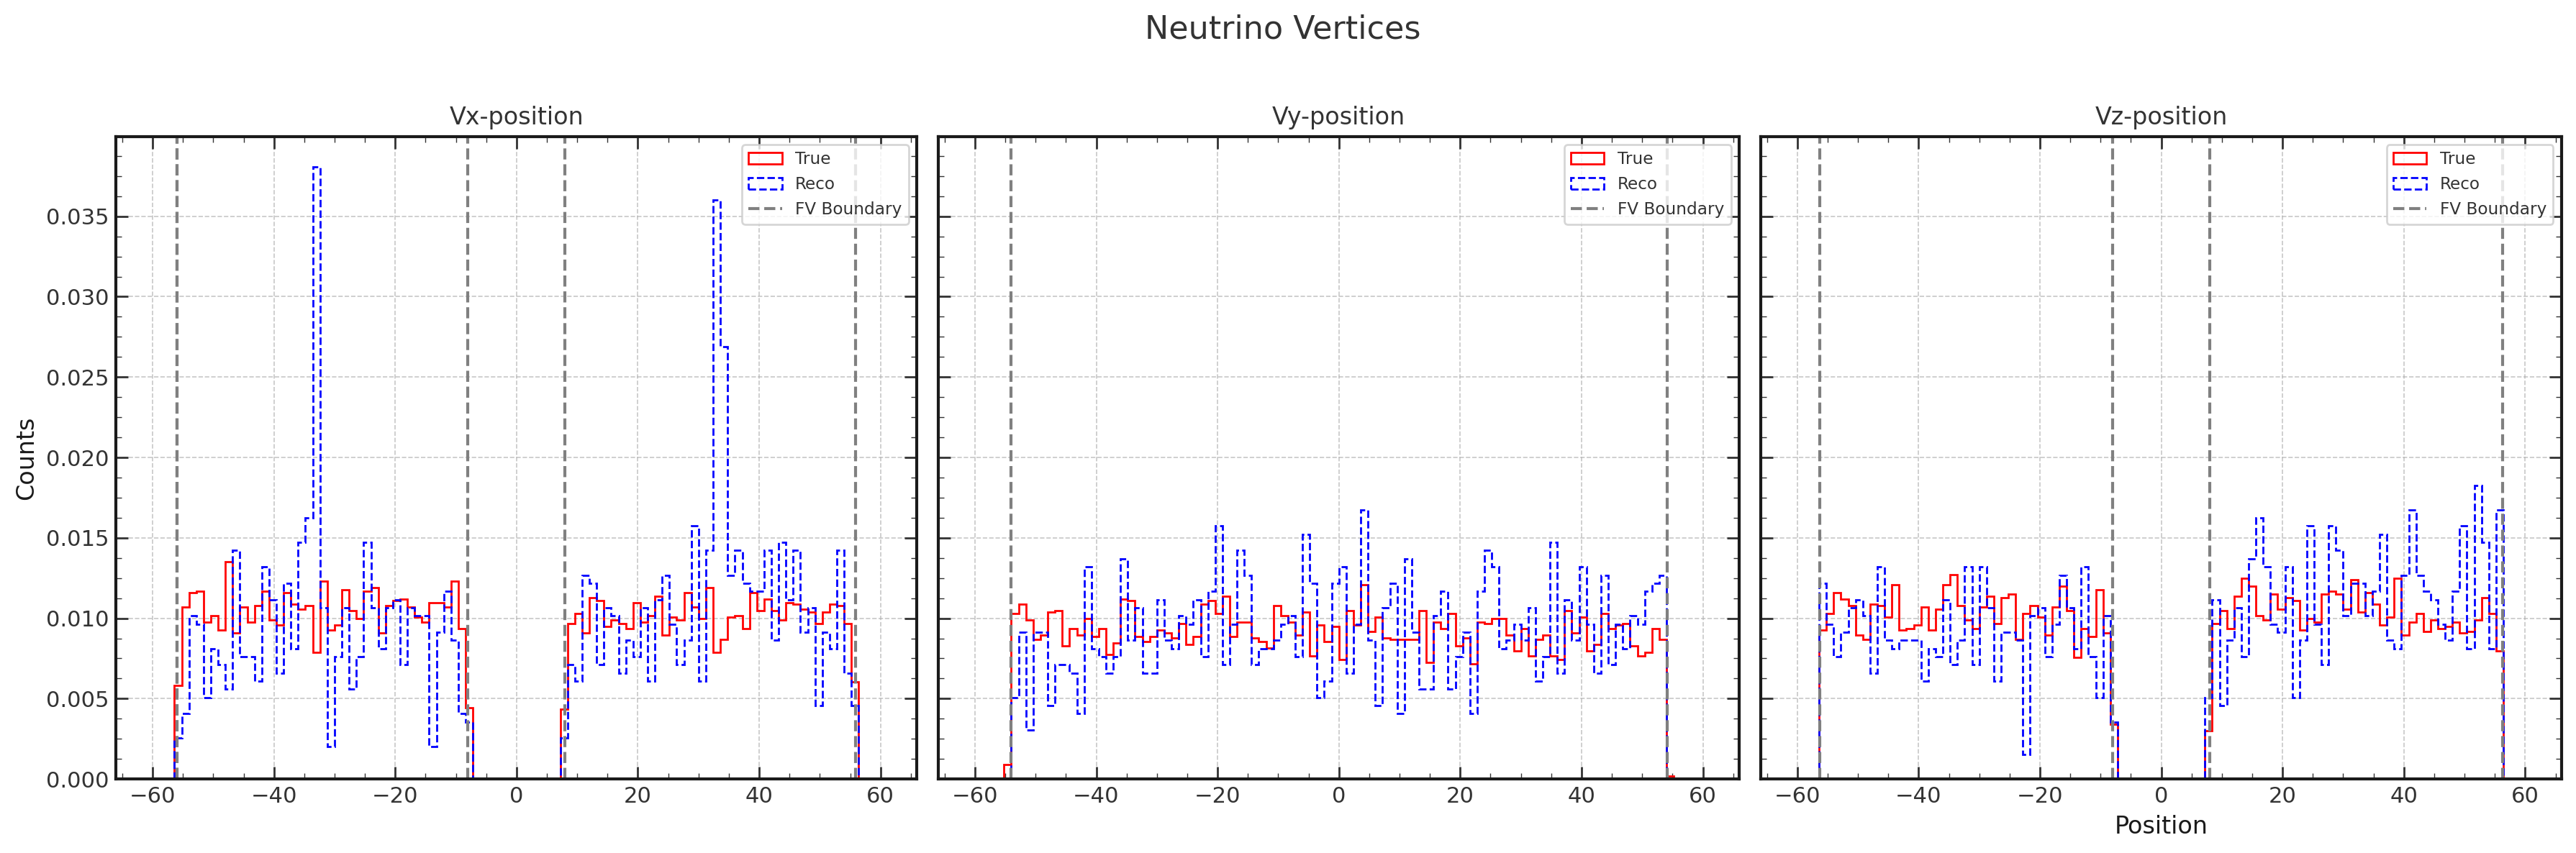

In [56]:
# Create a figure and a set of subplots in a 1x3 layout
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Plot the first histogram (vx-position)
axs[0].hist(vx_t, bins=100, histtype='step', range=[-60, 60], color='red', density=True, label=r'True')
axs[0].hist(vtx_x_signal, bins=100, histtype='step', range=[-60, 60], color='blue', density=True, linestyle='--',label=r'Reco')
axs[0].set_title('Vx-position')
axs[0].set_ylabel('Counts')
#axs[0].set_yscale('log')

# Add vertical lines
axs[0].axvline(x=xbound - tpc_dist, color='gray', linestyle='--', label='FV Boundary')
axs[0].axvline(x=-xbound + tpc_dist, color='gray', linestyle='--')
axs[0].axvline(x=+ tpc_dist, color='gray', linestyle='--')
axs[0].axvline(x=- tpc_dist, color='gray', linestyle='--')
axs[0].axvline(x=-xbound + tpc_dist, color='gray', linestyle='--')
axs[0].legend(loc='upper right', fontsize='small')

# Plot the second histogram (vy-position)
axs[1].hist(vy_t, bins=100, histtype='step', range=[-60, 60], color='red', density=True, label=r'True')
axs[1].hist(vtx_y_signal, bins=100, histtype='step', range=[-60, 60], color='blue', density=True, linestyle='--',label=r'Reco')
axs[1].set_title('Vy-position')
axs[1].axvline(x=ybound - tpc_dist, color='gray', linestyle='--', label='FV Boundary')
axs[1].axvline(x=-ybound + tpc_dist, color='gray', linestyle='--')
axs[1].legend(loc='upper right', fontsize='small')

# Plot the third histogram (vz-position)
axs[2].hist(vz_t, bins=100, histtype='step', range=[-60, 60], color='red', density=True, label=r'True')
axs[2].hist(vtx_z_signal, bins=100, histtype='step', range=[-60, 60], color='blue', density=True, linestyle='--',label=r'Reco')
axs[2].set_title('Vz-position')
axs[2].set_xlabel('Position')
# Add vertical lines
axs[2].axvline(x=zbound - tpc_dist, color='gray', linestyle='--', label='FV Boundary')
axs[2].axvline(x=-zbound + tpc_dist, color='gray', linestyle='--')
axs[2].axvline(x=+ tpc_dist, color='gray', linestyle='--')
axs[2].axvline(x=- tpc_dist, color='gray', linestyle='--')
axs[2].legend(loc='upper right', fontsize='small')
# Add a main title to the entire figure
fig.suptitle('Neutrino Vertices ', fontsize=16)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust the bottom of the layout to make room for the main title

# Show the plot
plt.show()

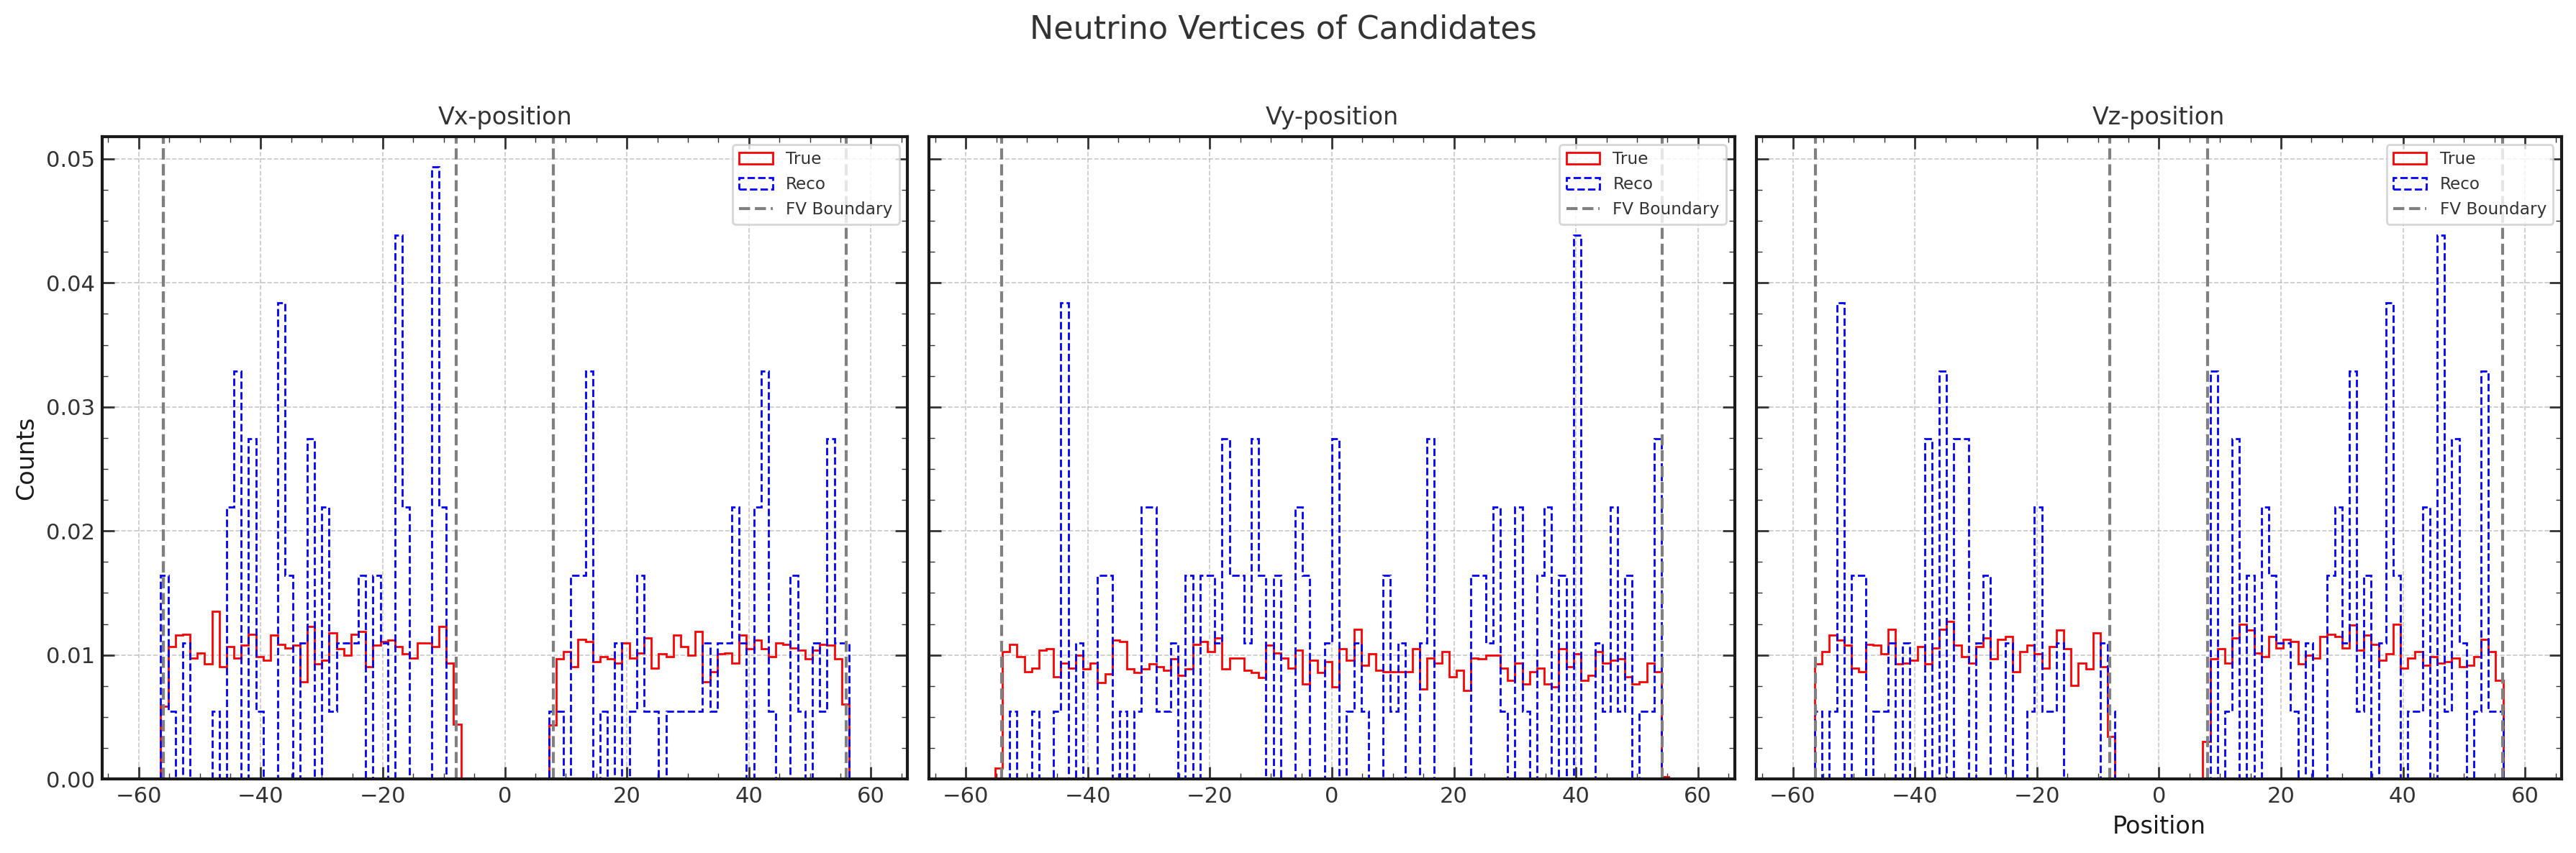

In [66]:
# Create a figure and a set of subplots in a 1x3 layout
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
# Plot the first histogram (vx-position)
axs[0].hist(vx_t, bins=100, histtype='step', range=[-60, 60], color='red', density=True, label=r'True')
axs[0].hist(vtx_x_candidates, bins=100, histtype='step', range=[-60, 60], color='blue', density=True, linestyle='--',label=r'Reco')
axs[0].set_title('Vx-position')
axs[0].set_ylabel('Counts')
#axs[0].set_yscale('log')

# Add vertical lines
axs[0].axvline(x=xbound - tpc_dist, color='gray', linestyle='--', label='FV Boundary')
axs[0].axvline(x=-xbound + tpc_dist, color='gray', linestyle='--')
axs[0].axvline(x=+ tpc_dist, color='gray', linestyle='--')
axs[0].axvline(x=- tpc_dist, color='gray', linestyle='--')
axs[0].axvline(x=-xbound + tpc_dist, color='gray', linestyle='--')
axs[0].legend(loc='upper right', fontsize='small')

# Plot the second histogram (vy-position)
axs[1].hist(vy_t, bins=100, histtype='step', range=[-60, 60], color='red', density=True, label=r'True')
axs[1].hist(vtx_y_candidates, bins=100, histtype='step', range=[-60, 60], color='blue', density=True, linestyle='--',label=r'Reco')
axs[1].set_title('Vy-position')
axs[1].axvline(x=ybound - tpc_dist, color='gray', linestyle='--', label='FV Boundary')
axs[1].axvline(x=-ybound + tpc_dist, color='gray', linestyle='--')
axs[1].legend(loc='upper right', fontsize='small')

# Plot the third histogram (vz-position)
axs[2].hist(vz_t, bins=100, histtype='step', range=[-60, 60], color='red', density=True, label=r'True')
axs[2].hist(vtx_z_candidates, bins=100, histtype='step', range=[-60, 60], color='blue', density=True, linestyle='--',label=r'Reco')
axs[2].set_title('Vz-position')
axs[2].set_xlabel('Position')
# Add vertical lines
axs[2].axvline(x=zbound - tpc_dist, color='gray', linestyle='--', label='FV Boundary')
axs[2].axvline(x=-zbound + tpc_dist, color='gray', linestyle='--')
axs[2].axvline(x=+ tpc_dist, color='gray', linestyle='--')
axs[2].axvline(x=- tpc_dist, color='gray', linestyle='--')
axs[2].legend(loc='upper right', fontsize='small')
# Add a main title to the entire figure
fig.suptitle('Neutrino Vertices of Candidates ', fontsize=16)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust the bottom of the layout to make room for the main title

# Show the plot
plt.show()

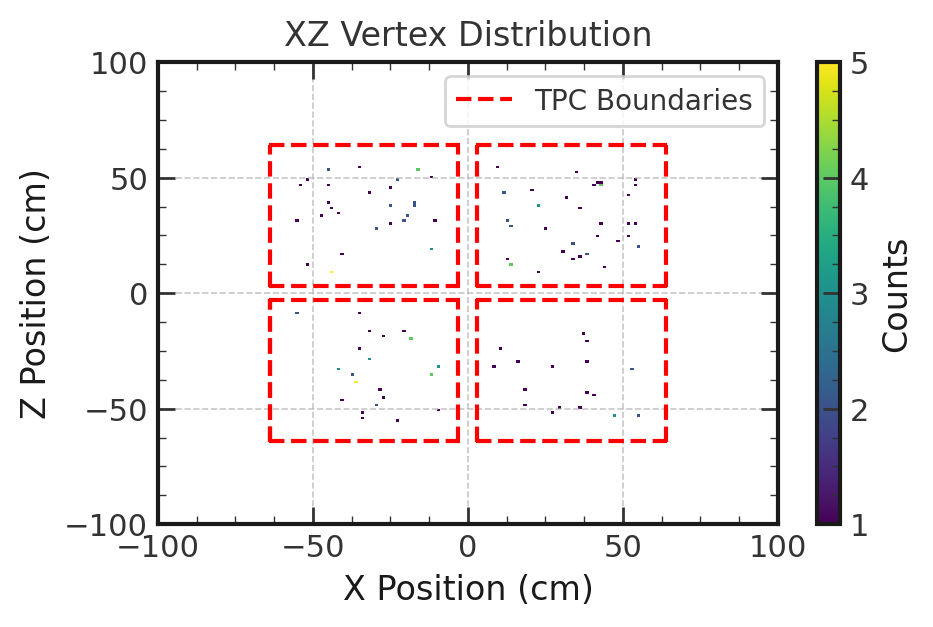

In [70]:
plt.hist2d(vtx_x_candidates, vtx_z_candidates, bins=100, cmap='viridis', cmin=0.01)
for i in range(0,8):
    plt.plot(traces_anode[i]['z'][1], traces_anode[i]['x'][1], 'r--')
    plt.plot(traces_anode[i]['x'][1], traces_anode[i]['z'][1], 'r--')
plt.plot(traces_anode[0]['x'][1], traces_anode[0]['z'][1],'r--',label='TPC Boundaries')
plt.title('XZ Vertex Distribution')
plt.xlabel('X Position (cm)')
plt.ylabel('Z Position (cm)')
plt.colorbar(label='Counts')
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.legend()

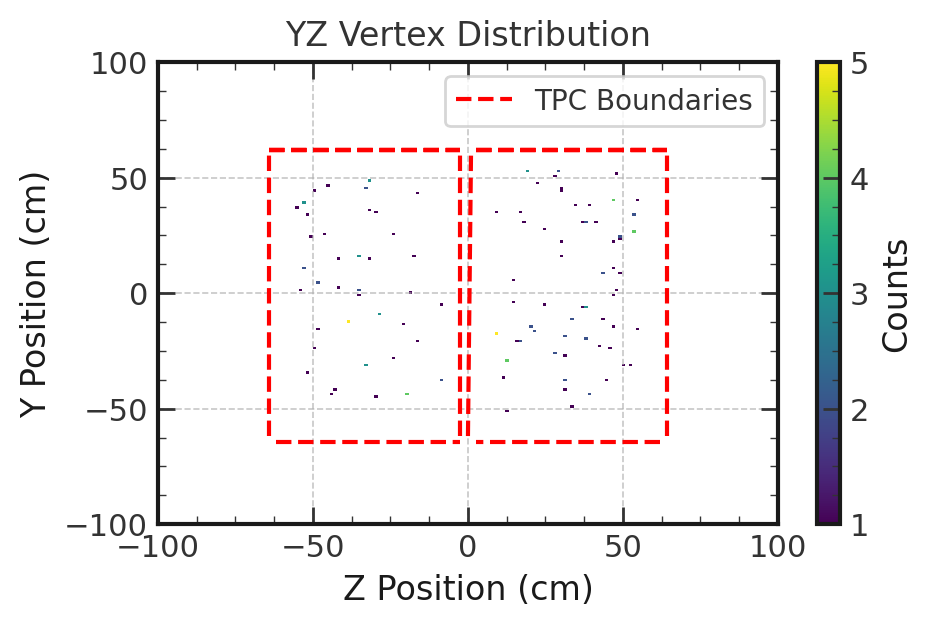

In [69]:
plt.hist2d(vtx_z_candidates, vtx_y_candidates, bins=100, cmap='viridis', cmin=0.01)
for i in range(0,8):
    plt.plot(traces_anode[i]['z'][1], traces_anode[i]['y'][1], 'r--')
#     plt.plot(traces_anode[i]['y'][1], traces_anode[i]['z'][1], 'r--')
plt.plot([-traces_anode[0]['y'][1][1], traces_anode[0]['y'][1][1]],'r--',label='TPC Boundaries')
plt.plot([-64.3163,-64.3163 ],[-61.8543,61.8543], 'r--')
plt.plot([64.3163,64.3163 ],[-61.8543,61.8543], 'r--')
plt.plot([-2.6837,-2.6837 ],[-61.8543,61.8543], 'r--')
plt.plot([-61.8543,-2.6837], [-64.3163,-64.3163 ],'r--')
plt.plot([61.8543,2.6837], [-64.3163,-64.3163 ],'r--')
plt.title('YZ Vertex Distribution')
plt.xlabel('Z Position (cm)')
plt.ylabel('Y Position (cm)')
plt.colorbar(label='Counts')
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.legend()

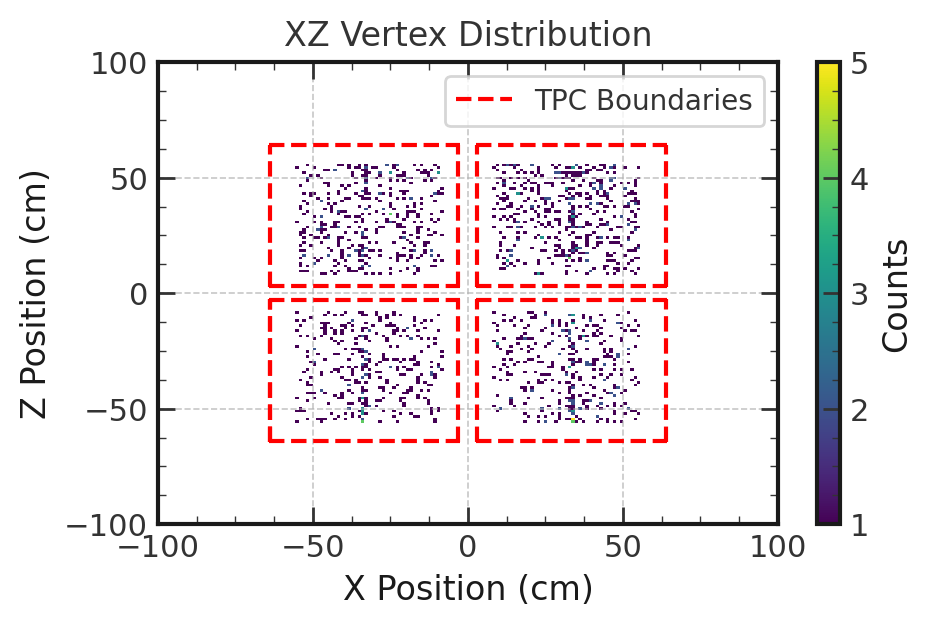

In [67]:
plt.hist2d(vtx_x_signal, vtx_z_signal, bins=100, cmap='viridis', cmin=0.01)
for i in range(0,8):
    plt.plot(traces_anode[i]['z'][1], traces_anode[i]['x'][1], 'r--')
    plt.plot(traces_anode[i]['x'][1], traces_anode[i]['z'][1], 'r--')
plt.plot(traces_anode[0]['x'][1], traces_anode[0]['z'][1],'r--',label='TPC Boundaries')
plt.title('XZ Vertex Distribution')
plt.xlabel('X Position (cm)')
plt.ylabel('Z Position (cm)')
plt.colorbar(label='Counts')
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.legend()